# Weekday and Weekend Differences in Shared Mobility Patterns

## A Bike-Share Case Study Using 2025 Chicago Divvy Data

This notebook is the proposal-facing summary layer. The reproducible data cleaning and analysis pipeline stays in `src/`, while this notebook reads the generated CSV tables and figures from `outputs/` and `figures/`.

In [ ]:
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

OUTPUTS = ROOT / "outputs"
FIGURES = ROOT / "figures"

pd.options.display.float_format = "{:,.3f}".format

def read_output_csv(filename):
    path = OUTPUTS / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing output file: {path}. Run the src pipeline first.")
    return pd.read_csv(path)

def show_png(filename, figsize=(8, 5)):
    path = FIGURES / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing figure file: {path}. Run the src pipeline first.")
    image = mpimg.imread(path)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    ax.axis("off")
    plt.show()

ModuleNotFoundError: No module named 'pandas'

## Research Question

How do shared bike mobility patterns differ between weekdays and weekends in Chicago during 2025?

The proposal focuses on three core mobility signals:

- Trip duration
- Straight-line trip length
- Start-location spatial density

A station-level dwell time proxy is included as a secondary metric. It is not bike-level dwell time because the public Divvy dataset does not include `bike_id`.

## Data and Reproducible Pipeline

The project uses monthly 2025 Chicago Divvy trip CSV files. The source data is cleaned and summarized with Python scripts in `src/`:

1. `01_combine_and_clean.py`
2. `02_eda_trip_patterns.py`
3. `03_dwell_proxy.py`
4. `04_spatial_heatmaps.py`
5. `05_optional_weather_merge.py`

This notebook does not replace those scripts. It only presents the already generated outputs for proposal writing.

In [ ]:
cleaning_summary = read_output_csv("cleaning_summary.csv")
weekday_weekend_counts = read_output_csv("weekday_weekend_counts.csv")
monthly_counts = read_output_csv("monthly_counts_by_day_type.csv")
trip_summary = read_output_csv("trip_summary_by_day_type.csv")
dwell_summary = read_output_csv("dwell_proxy_summary_by_day_type.csv")

## Cleaning Summary

The cleaning pipeline removes invalid timestamps, trips outside the 2025 analysis year, missing or invalid coordinates, invalid durations, and unrealistic straight-line distances.

In [ ]:
display(cleaning_summary)

,stage,rows,removed_since_previous_stage
0,original rows,5552994,0
1,rows after timestamp filter,5552994,0
2,rows after 2025 started_at filter,5552941,53
3,rows after coordinate filter,5547406,5535
4,rows after duration filter,5547168,238
5,rows after distance filter,5547168,0
6,final rows,5547168,0


## Weekday vs Weekend Trip Counts

This table gives the overall sample balance between weekday and weekend trips.

In [ ]:
counts_for_display = weekday_weekend_counts.copy()
counts_for_display["share_percent"] = counts_for_display["share"] * 100
display(counts_for_display)

,day_type,trip_count,share,share_percent
0,weekday,3970986,0.716,71.586
1,weekend,1576182,0.284,28.414


## Monthly Coverage

The monthly count figure shows that the analysis covers the full year instead of a single seasonal snapshot.

day_type,weekday,weekend
month_name,,
Jan,111017,27565
Feb,119044,32788
Mar,214828,83055
Apr,278775,92286
May,358992,143012
Jun,458222,219592
Jul,560340,202111
Aug,508760,280826
Sep,524082,189876


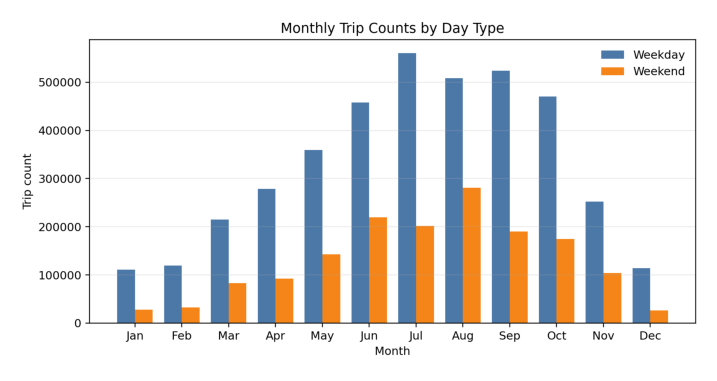

In [ ]:
monthly_pivot = monthly_counts.pivot(index="month_name", columns="day_type", values="trip_count")
month_order = monthly_counts.drop_duplicates("month").sort_values("month")["month_name"]
monthly_pivot = monthly_pivot.reindex(month_order)
display(monthly_pivot)
show_png("monthly_trip_counts_by_day_type.png", figsize=(9, 5))

## Trip Duration and Trip Length

The summary statistics use the cleaned full dataset. The boxplots hide extreme visual outliers by limiting the displayed y-axis range, but the table below is based on all filtered records.

In [ ]:
display(trip_summary)

,metric,day_type,count,mean,median,q1,q3,min,max
0,trip_duration_minutes,weekday,3970986,13.473,8.976,5.227,15.462,0.001,"1,439.827"
1,trip_duration_minutes,weekend,1576182,17.151,10.758,5.915,19.506,0.001,"1,439.976"
2,trip_length_km,weekday,3970986,2.178,1.598,0.909,2.831,0.000,40.565
3,trip_length_km,weekend,1576182,2.265,1.657,0.904,2.998,0.000,37.261


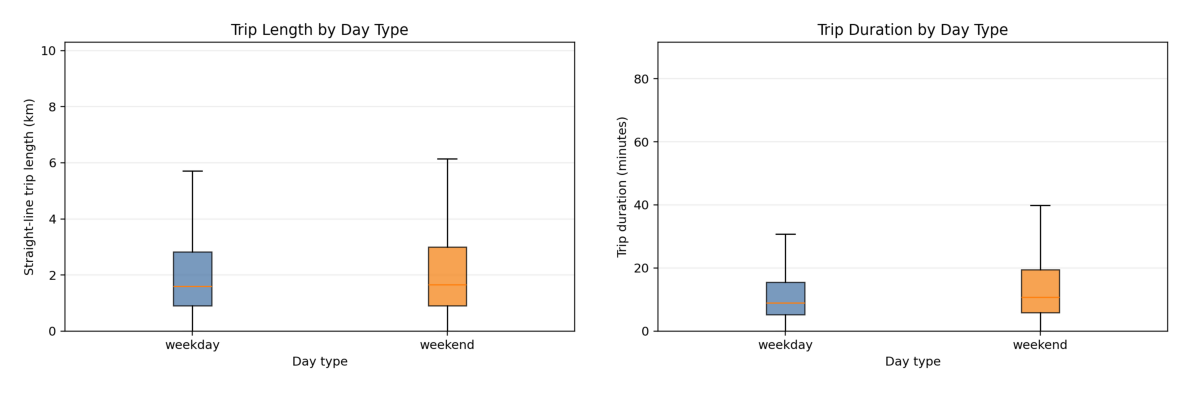

In [ ]:
figure_names = ["trip_length_boxplot.png", "trip_duration_boxplot.png"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, filename in zip(axes, figure_names):
    image = mpimg.imread(FIGURES / filename)
    ax.imshow(image)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Spatial Start-location Density

The side-by-side heatmap is the strongest proposal figure because it directly shows whether weekday and weekend trips concentrate in different parts of the city. The figure uses longitude and latitude bins rather than a basemap, which keeps the visualization reproducible and dependency-light.

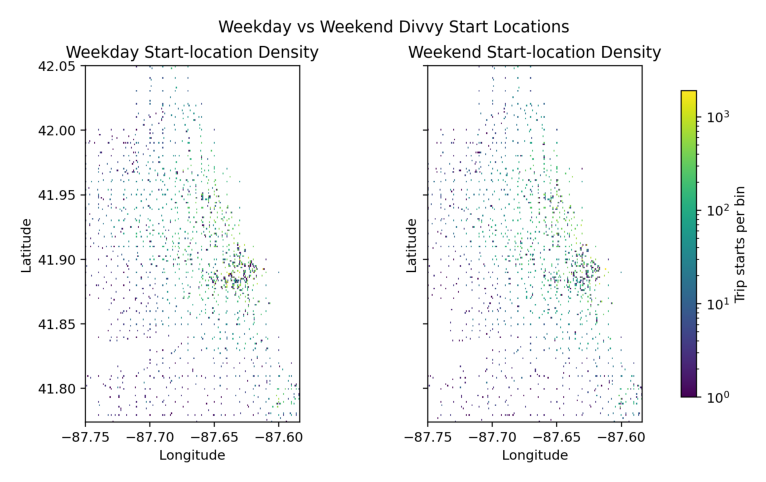

In [ ]:
show_png("heatmap_start_locations_weekday_weekend.png", figsize=(11, 6))

## Station-level Dwell Time Proxy

The dwell proxy is calculated as the time from an arrival event at a station to the next departure event at the same station. This should be described as a station-level availability or idle-time proxy, not as true bike-level dwell time.

,day_type,count,mean,median,q1,q3
0,weekday,3074864,66.206,15.766,4.710,48.155
1,weekend,1197013,67.115,15.092,4.117,47.809


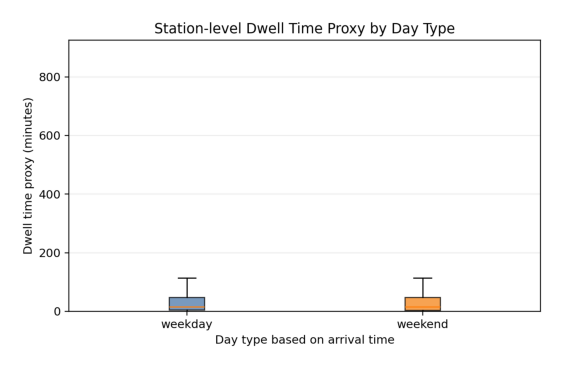

In [ ]:
display(dwell_summary)
show_png("dwell_proxy_boxplot.png", figsize=(7, 5))

## Recommended Proposal Figures

For a 2-page proposal, use only the highest-value figures:

1. `heatmap_start_locations_weekday_weekend.png` - best figure for the core spatial weekday/weekend difference.
2. `monthly_trip_counts_by_day_type.png` or `trip_length_boxplot.png` - use monthly counts to show full-year coverage, or trip length to show behavioral difference.

If space is tight, put trip duration and trip length in the summary table instead of adding both boxplots.

## Limitations and Next Steps

Key limitations:

- Straight-line distance is not the actual route distance.
- Public Divvy data does not include `bike_id`, so dwell time can only be measured as a station-level proxy.
- Weather is optional for the proposal and should be treated as a final-project extension.

Final project extensions:

- Compare member and casual riders.
- Add time-of-day and seasonal analysis.
- Merge daily NOAA weather fields such as TMAX, TMIN, PRCP, and SNOW.
- Rank station hotspots by weekday/weekend differences.
- Add simple statistical tests for duration and trip-length differences.